In [1]:
import torch 
torch.cuda.is_available()

False

In [2]:
import sys
sys.path.append('../../utils')
from functions import * 

In [3]:
from importlib import reload
import sys

# Path to the Leaflet repository
PATH_TO_LEAFLET_REPO = '/gpfs/commons/home/kisaev/Leaflet/src/beta-binomial-mix/'
sys.path.append(PATH_TO_LEAFLET_REPO)

In [4]:
import pyro
import pyro.distributions as dist
from pyro.infer.autoguide import AutoDiagonalNormal, AutoGuideList, AutoDelta, AutoMultivariateNormal
from pyro.infer import SVI, Trace_ELBO, RenyiELBO, Predictive
from pyro.distributions import constraints
import matplotlib.pyplot as plt
import math

In [5]:
from importlib import reload
#from load_cluster_data import load_cluster_data
from betabinomo_mix_singlecells import *
#reload(betabinomo_mix_singlecells)
from cell_state_asign_consistency import *
#reload(cell_state_asign_consistency)
import load_cluster_data

import torch
import sklearn.manifold 
import plotnine as p9
import time
# indicate plot should be small 4 by 4
import plotnine as p9
from plotnine import ggplot, geom_point, aes, stat_smooth, facet_wrap, geom_violin, theme, element_blank, geom_text, geom_bar, geom_hline
import plotnine
from tqdm import tqdm
plotnine.options.figure_size = (4, 4)
import seaborn as sns
sns.set_theme(style="whitegrid")

/gpfs/commons/home/kisaev/.local/lib/python3.9/site-packages/statsmodels/compat/pandas.py:65: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.


In [6]:
def quick_clust_plot(clust, simple_data):
    simple_data_junc = simple_data[simple_data["Cluster"] == clust]
    # make violin plot with jitter 
    print(simple_data_junc.cell_type.value_counts())
    print(simple_data_junc.gene_id.unique())
    print(simple_data_junc.junction_id.unique())
    plt.figuresize=(6, 6)
    sns.violinplot(data = simple_data_junc, x = "juncratio", y = "cell_type", hue="junction_id_index")
    # make xlim -1 to 1.1
    plt.xlim(-0.2, 1.2)
    # add sample_label to title 
    plt.title("cluster:" + str(clust), fontsize=16)
    # set x axis label to "Junction Usage Ratio (PSI)"
    plt.xlabel("Junction Usage Ratio (PSI)", fontsize=20)
    plt.ylabel("Cell Type Group", fontsize=20)
    # increase x and y tick label size to 14
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.show()

### Settings and Load data

In [7]:
torch.manual_seed(42)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

K = 50 # set to very high number 

float_type = { 
    "device" : device, 
    "dtype" : torch.float, # save memory
}

hypers = {
    "eta" : 1./K, 
    "alpha_prior" : 1, # karin had 0.65 
    "pi_prior" : 1 
}

print(hypers["eta"])

cpu
0.02


In [8]:
# this folder contains input data for each tissue cell type sample
#input_files_folder = '/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisMuscle/muscle/'
input_files_folder = '/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/MLCB_Brain_true/FULL/'

cell_types = ['Brain_Non-Myeloid_brain_pericyte','Brain_Non-Myeloid_oligodendrocyte_precursor_cell','Brain_Non-Myeloid_endothelial_cell','Brain_Non-Myeloid_oligodendrocyte',
 'Brain_Non-Myeloid_neuron', 'Brain_Myeloid_macrophage',
 'Brain_Myeloid_microglial_cell', 'Brain_Non-Myeloid_astrocyte']

# convert data to Leaflet required input formats 
final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = load_cluster_data.load_cluster_data(
    input_folder = input_files_folder, max_intron_count=5000, has_genes="yes", celltypes=cell_types) 

# add cluster to final_data 
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index"], how="left")

# still do preprocessing in scipy
import scipy.sparse as sp
indices = (final_data.cell_id_index, final_data.junction_id_index)
indices_np = np.stack(indices)
junc_counts = sp.coo_matrix((final_data.junc_count, indices))
cluster_counts = sp.coo_matrix((final_data.cluster_count, indices))

# sanity check that counts are saved in correct indices in sparse matrices
ind_random = np.random.randint(0, len(final_data))
print(final_data.iloc[ind_random])
print(junc_counts.toarray()[final_data.iloc[ind_random].cell_id_index, final_data.iloc[ind_random].junction_id_index])
print(cluster_counts.toarray()[final_data.iloc[ind_random].cell_id_index, final_data.iloc[ind_random].junction_id_index])

Reading in data from folder ...
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/MLCB_Brain_true/FULL/
Finished reading in data from folder ...
Looking at only specific cell types ...['Brain_Non-Myeloid_brain_pericyte', 'Brain_Non-Myeloid_oligodendrocyte_precursor_cell', 'Brain_Non-Myeloid_endothelial_cell', 'Brain_Non-Myeloid_oligodendrocyte', 'Brain_Non-Myeloid_neuron', 'Brain_Myeloid_macrophage', 'Brain_Myeloid_microglial_cell', 'Brain_Non-Myeloid_astrocyte']
['Brain_Non-Myeloid_brain_pericyte'
 'Brain_Non-Myeloid_oligodendrocyte_precursor_cell'
 'Brain_Non-Myeloid_endothelial_cell' 'Brain_Non-Myeloid_oligodendrocyte'
 'Brain_Non-Myeloid_neuron' 'Brain_Myeloid_macrophage'
 'Brain_Myeloid_microglial_cell' 'Brain_Non-Myeloid_astrocyte']
7816
16190
The maximum junction count was initially:  150346
80
The maximum junction count is now:  4982
                                             cell_id  Cluster  Cluster_Counts  \
0  A14-MAA000581-3_10_M-1-1_Brain_Non-M

In [9]:
cell_index_tensor, junc_index_tensor, my_data = make_torch_data(final_data, **float_type)

The number of cells going into training data is:
7816
7816


/gpfs/commons/home/kisaev/Leaflet/src/beta-binomial-mix/betabinomo_mix_singlecells.py:333: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ../aten/src/ATen/SparseCsrTensorImpl.cpp:53.)


In [10]:
simple_data = final_data[["cell_id_index", "Cluster", "cell_type", "junction_id_index", "juncratio", "junc_count", "cluster_count",  "junction_id", "gene_id"]]
# get true PSI for each Cluster 
simple_data.head()

,cell_id_index,Cluster,cell_type,junction_id_index,juncratio,junc_count,cluster_count,junction_id,gene_id
0,0,4,Brain_Non-Myeloid_brain_pericyte,0,0.523810,11.0,21,1_160044753_160070699,4930523C07Rik
1,0,4,Brain_Non-Myeloid_brain_pericyte,1,0.476190,10.0,21,1_160070803_160075030,4930523C07Rik
2,0,10,Brain_Non-Myeloid_brain_pericyte,2,1.000000,16.0,16,1_155567681_155572197,Acbd6
3,0,27,Brain_Non-Myeloid_brain_pericyte,3,1.000000,7.0,7,1_36307836_36316208,Arid5a
4,0,28,Brain_Non-Myeloid_brain_pericyte,4,0.416667,5.0,12,1_36316327_36317609,Arid5a


In [11]:
simple_data.Cluster.unique()

array([   4,   10,   27, ..., 5172, 9599,  191])

In [12]:
# let's visualize junction usage ratios for a given custer 
clust = 109 
#quick_clust_plot(clust, simple_data)

<Axes: xlabel='juncratio', ylabel='Density'>

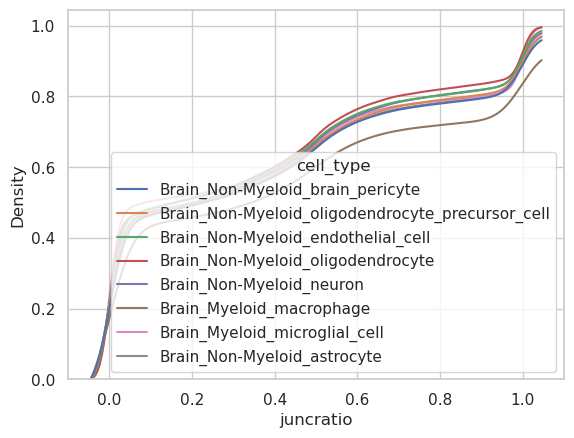

In [13]:
# use junctionratio column in final data to make histogram adn colour by cell_Type
final_data
# make density plot instead of histogram
# sns.kdeplot(data=final_data, x="juncratio", hue="cell_type", fill=True, common_norm=False, alpha=.5)
# add facet for cell_type
sns.kdeplot(data=final_data, x="juncratio", hue="cell_type", cumulative=True, common_norm=False, common_grid=True)

In [14]:
from sklearn.impute import SimpleImputer

In [15]:
# make matrix of junctions by cells and fill with juncratio values 
mat = np.zeros((len(final_data.cell_id_index.unique()), len(final_data.junction_id_index.unique())))
mat[final_data.cell_id_index, final_data.junction_id_index] = final_data.juncratio
mat[~(final_data.cell_id_index), ~(final_data.junction_id_index)] = np.nan
mat 

array([[0.52380952, 0.47619048, 1.        , ..., 0.        , 0.        ,
        0.        ],
       [0.44166667, 0.55833333, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.26315789, 0.73684211, 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        ,        nan,
               nan],
       [0.        , 0.        , 0.        , ..., 0.        ,        nan,
               nan],
       [0.        , 0.        , 0.        , ...,        nan,        nan,
               nan]])

In [16]:
# imput nan values using mean of each row
imp = SimpleImputer(missing_values=np.nan, strategy='mean')
imp.fit(mat)
mat_imputed = imp.transform(mat)
mat_imputed 
mat_imputed 

array([[5.23809524e-01, 4.76190476e-01, 1.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [4.41666667e-01, 5.58333333e-01, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [2.63157895e-01, 7.36842105e-01, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 4.03605543e-04],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 4.03605543e-04],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        4.35226718e-04, 0.00000000e+00, 4.03605543e-04]])

In [17]:
# run PCA on mat_imputed 
from sklearn.decomposition import PCA
pca = PCA(n_components=10)
pca.fit(mat_imputed)
pca.components_
pca.explained_variance_ratio_

array([0.0672032 , 0.01925902, 0.01560112, 0.01093991, 0.00515439,
       0.00346535, 0.00298153, 0.00264373, 0.00224747, 0.00208012])

In [18]:
# Plot PCs 
# make dataframe with PCs
pcs = pca.transform(mat_imputed)
pcs_df = pd.DataFrame(pcs, columns=["PC1", "PC2", "PC3", "PC4", "PC5", "PC6", "PC7", "PC8", "PC9", "PC10"])
pcs_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,1.805613,3.087370,-1.841338,-0.782697,-0.960958,5.716895,-0.423583,0.912874,0.508178,-0.093297
1,1.304068,3.046929,-2.276292,-1.080747,-0.084521,5.313308,1.117235,0.839099,0.534146,-0.163627
2,0.127851,1.453324,-2.634727,-0.154226,-0.773564,4.538526,-0.241550,0.830606,-1.613022,0.321981
3,2.037056,3.776720,-1.863305,-0.705702,-0.661678,6.788439,0.881705,1.021384,-0.007432,-0.395214
4,1.819825,3.651949,-1.923252,-1.267519,-0.610409,6.653674,1.590590,0.653906,-0.212720,-1.193993


Text(0.5, 1.0, 'PCA of Junction Usage Ratios (imputed matrix)')

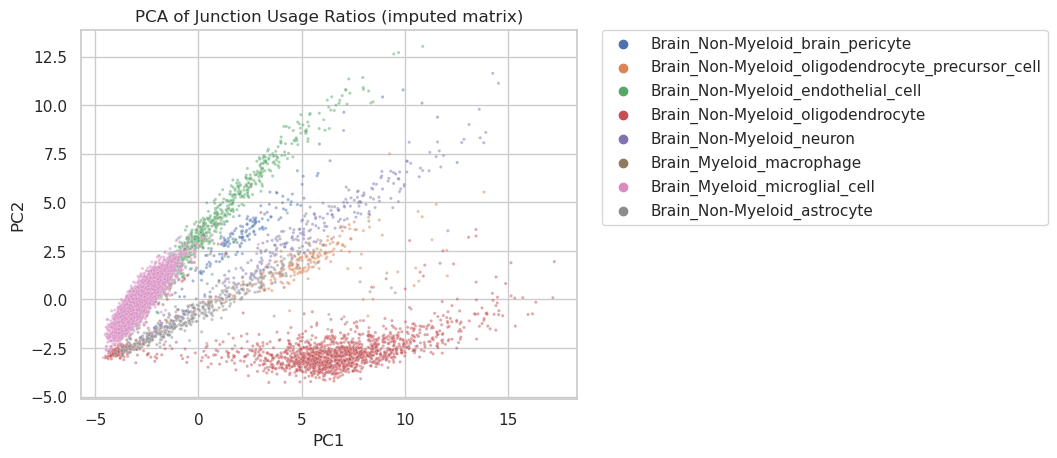

In [19]:
cell_types_pcs = cell_ids_conversion["cell_type"]
# plot first two PCs
sns.scatterplot(data=pcs_df, x="PC1", y="PC2", hue=cell_types_pcs.values, s=5, alpha=0.5)
# move legend outside of plot
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.title("PCA of Junction Usage Ratios (imputed matrix)")

Text(0.5, 1.0, 'PCA of Junction Usage Ratios (imputed matrix)')

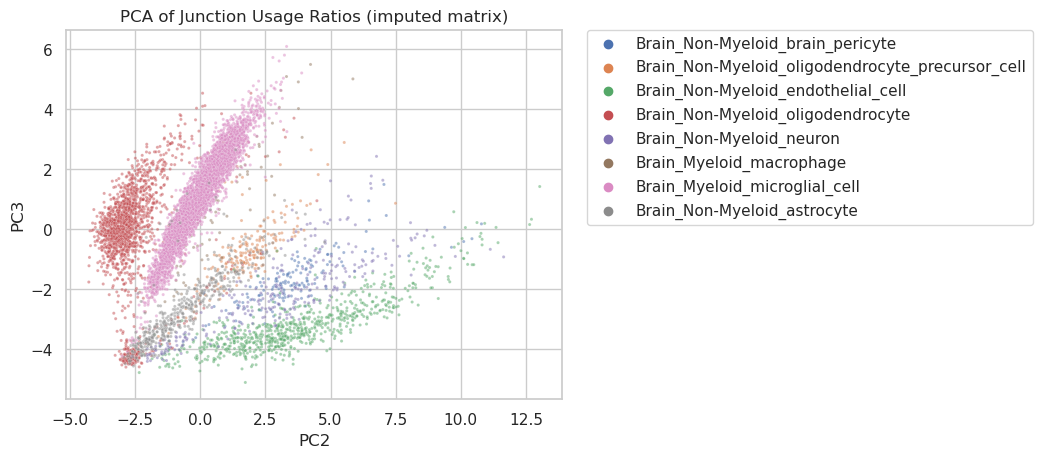

In [20]:
# plot first two PCs
sns.scatterplot(data=pcs_df, x="PC2", y="PC3", hue=cell_types_pcs.values, s=5, alpha=0.5)
# move legend outside of plot
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.title("PCA of Junction Usage Ratios (imputed matrix)")

Text(0.5, 1.0, 'PCA of Junction Usage Ratios (imputed matrix)')

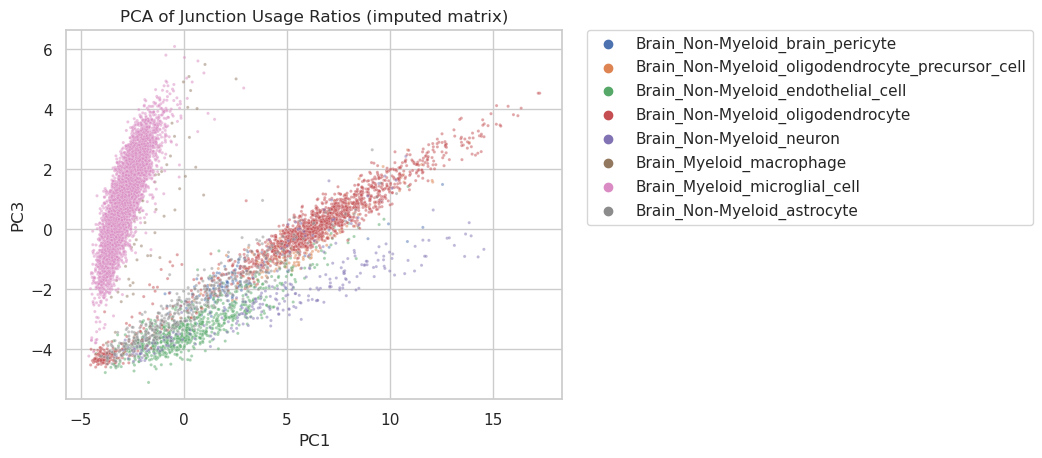

In [21]:
# plot first two PCs
sns.scatterplot(data=pcs_df, x="PC1", y="PC3", hue=cell_types_pcs.values, s=5, alpha=0.5)
# move legend outside of plot
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.title("PCA of Junction Usage Ratios (imputed matrix)")

In [22]:
# get total junction and cluster counts (coverage) per cell 
# plot histogram of coverage

cell_junc_cov = final_data.groupby("cell_id_index").junc_count.sum()
cell_cluster_cov = final_data.groupby("cell_id_index").cluster_count.sum()

Text(0.5, 1.0, 'Junction Coverage per Cell')

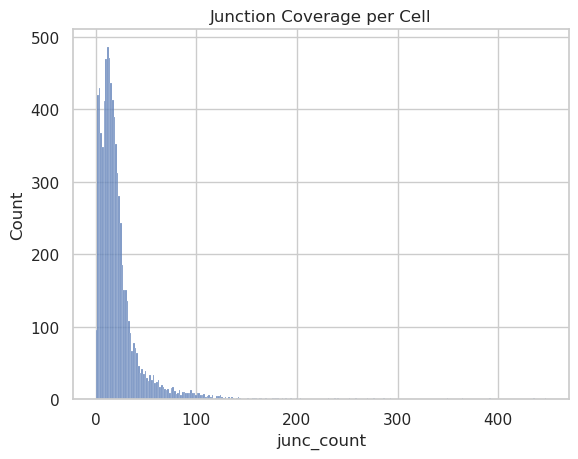

In [23]:
# plot histogram of coverage
sns.histplot(cell_junc_cov/1000)
plt.title("Junction Coverage per Cell")

Text(0.5, 1.0, 'Cluster Coverage per Cell')

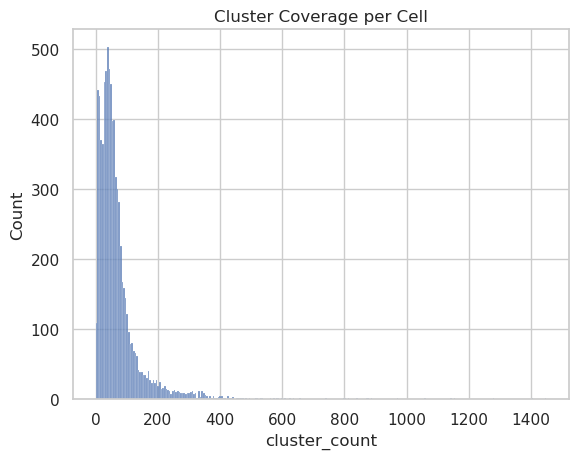

In [24]:
# plot histogram of coverage clusters 
sns.histplot(cell_cluster_cov/1000)
plt.title("Cluster Coverage per Cell")

In [25]:
def my_log_prob(y_sparse, total_counts_sparse, pred):
    
    # Extract non-zero elements and their indices from y and total_counts
    y_indices = y_sparse._indices()
    y_values = y_sparse._values()

    total_counts_indices = total_counts_sparse._indices()
    total_counts_values = total_counts_sparse._values()

    # Ensure that y and total_counts align on the same indices
    assert torch.equal(y_indices, total_counts_indices)

    # Compute log probabilities at these indices
    log_probs = dist.Binomial(total_counts_values, pred[y_indices[0], y_indices[1]]).log_prob(y_values)

    # Sum the log probabilities
    return log_probs.sum()

In [26]:
if device == torch.device('cuda'):
    torch.set_default_tensor_type('torch.cuda.FloatTensor')

def model(y, total_counts, K):
    N, P = y.shape

    a = pyro.sample("a", dist.Gamma(1., 1.).expand([P]).to_event(1))
    b = pyro.sample("b", dist.Gamma(1., 1.).expand([P]).to_event(1))

    psi_dist = dist.Beta(a, b).expand([K, P]).to_event(2)
    psi = pyro.sample("psi", psi_dist)

    pi = pyro.sample("pi", dist.Dirichlet(torch.ones(K) / K))
    conc = pyro.sample("conc", dist.Gamma(1, 1))

    with pyro.plate('data1', N):
        assign_dist = dist.Dirichlet(pi * conc)
        assign = pyro.sample("assign", assign_dist)

    pred = torch.mm(assign, psi)

    # Use custom log probability
    log_prob = my_log_prob(y, total_counts, pred) # double check that I am not double summing here 
    pyro.factor("obs", log_prob.sum())
    #pyro.factor("obs", log_prob)

In [27]:
def fit(y, total_counts, K, guide, patience=10, min_delta=0.01, lr=0.05, num_epochs=500):
    adam = pyro.optim.Adam({"lr": lr})
    svi = SVI(model, guide, adam, loss=Trace_ELBO())
    pyro.clear_param_store()
    losses = []
    best_loss = float('inf')
    epochs_since_improvement = 0

    for j in range(num_epochs):
        loss = svi.step(y, total_counts, K)
        losses.append(loss)

        # Check for improvement
        if best_loss - loss > min_delta:
            best_loss = loss
            epochs_since_improvement = 0
        else:
            epochs_since_improvement += 1

        # Early stopping check
        if epochs_since_improvement >= patience:
            print(f"Stopping early at epoch {j}")
            break

        if j % 10 == 0:
            print(f"Epoch {j}, Loss: {loss}")

        #torch.cuda.empty_cache()  # Attempt to free unused memory
    return losses

In [28]:
indices = torch.tensor(final_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values = torch.tensor(final_data['junc_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells = final_data['cell_id_index'].max() + 1
num_junctions = final_data['junction_id_index'].max() + 1
size = (num_cells, num_junctions)
# Create a sparse tensor
y_tensor = torch.sparse_coo_tensor(indices, values, size)

In [29]:
indices_counts = torch.tensor(final_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values_counts = torch.tensor(final_data['cluster_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells_counts = final_data['cell_id_index'].max() + 1
num_junctions_counts = final_data['junction_id_index'].max() + 1
size_counts = (num_cells_counts, num_junctions_counts)
# Create a sparse tensor
total_counts_tensor = torch.sparse_coo_tensor(indices_counts, values_counts, size_counts)

In [30]:
K = 50 # num factors
J = len(total_counts_tensor[0])
C = len(total_counts_tensor)
print(C, J, K)



7816 15929 50


In [31]:
losses = fit(y_tensor, total_counts_tensor, K, guide, lr=0.1, num_epochs=200)
plt.plot(losses, label = "Diagonal variational posterior")

NameError: name 'guide' is not defined

In [ ]:
# Sample from the guide (posterior)
guide_trace = pyro.poutine.trace(guide).get_trace(y_tensor, total_counts_tensor, K)

In [ ]:
# Extract the latent variables
latent_vars = {name: node["value"].detach().cpu().numpy() for name, node in guide_trace.nodes.items() if node["type"] == "sample"}

In [ ]:
latent_vars["conc"]

In [ ]:
# can we plot assign probabilityies for each cell
assign_post = latent_vars["assign"]
assign_post

In [ ]:
# make histgram of all the values in assign_post
plt.hist(assign_post.flatten(), bins=10)

In [ ]:
# Run PCA on assign_post
from sklearn.decomposition import PCA
pca = PCA(n_components=10)
pca.fit(assign_post)
X = pca.transform(assign_post)
X.shape

In [ ]:
# plot PCA
plt.scatter(X[:, 0], X[:, 1], s=1)
plt.xlabel("PC1")
plt.ylabel("PC2")

In [ ]:
# standardize values in assign_post
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(assign_post)
assign_post_scaled = scaler.transform(assign_post)
assign_post_scaled

In [ ]:
pca = PCA(n_components=10)
pca.fit(assign_post_scaled)
X = pca.transform(assign_post_scaled)
plt.scatter(X[:, 0], X[:, 1], s=1)
plt.xlabel("PC1")
plt.ylabel("PC2")


In [ ]:
row_indices = np.where(X[:, 0] > 10)
row_indices

In [ ]:
final_data[final_data["cell_id_index"] == 842].cluster_count.sum()

In [ ]:
# find row indices where values where PC1 is greater than 6
row_indices = np.where(X[:, 0] > 6)
row_indices

In [ ]:
# Step 1: Run UMAP
import umap

In [ ]:
# Step 2: Prepare cell type labels for coloring
cell_types = cell_ids_conversion['cell_type'].tolist()

In [ ]:
print(cell_ids_conversion.cell_type.value_counts())
# make a barplot of cell type counts
plt.figure(figsize=(10, 10))
sns.barplot(x = cell_ids_conversion.cell_type.value_counts().index, y = cell_ids_conversion.cell_type.value_counts())
plt.xticks(rotation=90)
plt.show()

In [ ]:
top_three_cell_types = cell_ids_conversion.cell_type.value_counts()[0:5].index.values
cell_types = cell_ids_conversion['cell_type'].apply(lambda x: x if x in top_three_cell_types else 'Other').tolist()

In [ ]:
# plot PCA results and color by cell type using sns
plt.figure(figsize=(6, 6))
sns.scatterplot(x = X[:, 0], y= X[:, 1], hue = cell_types, s=7, alpha=0.4)
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.show()

In [ ]:
plt.figure(figsize=(6, 6))
sns.scatterplot(x = X[:, 0], y= X[:, 2], hue = cell_types, s=7, alpha=0.4)
plt.xlabel("PCA1")
plt.ylabel("PCA3")
plt.show()

In [ ]:
reducer = umap.UMAP()
embedding = reducer.fit_transform(assign_post_scaled)  # Reducing to 2 dimensions

In [ ]:
# Plotting
plt.figure(figsize=(7, 7))
sns.scatterplot(
    x=embedding[:, 0], 
    y=embedding[:, 1], 
    hue=cell_types,
    alpha=0.4,
    palette=sns.color_palette("Set3", len(top_three_cell_types) + 1),  # +1 for 'Other' category
    legend='full'
)
plt.title("UMAP Projection of assign_post Colored by Cell Type")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.legend(title='Cell Type', bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

In [ ]:
# convert latent_vars["assign"] to pandas dataframe
assign_post_df = pd.DataFrame(assign_post)
assign_post_df.columns = ["factor_" + str(x) for x in assign_post_df.columns]   
assign_post_df.head()

In [ ]:
# get factor sums column wise 
factor_sums = assign_post_df.sum(axis=0)
# order factors by sums
factor_sums.sort_values(ascending=False, inplace=True)
# get top 10 factors
top_factors = factor_sums.index[0:10]
top_factors

In [ ]:
latent_vars["assign"][0].max()

In [ ]:
# get max value for every latent_vars["assign"]
max_factor = latent_vars["assign"].max(axis=1)
plt.hist(max_factor, bins=100, range=(0, 1))
# label x axis 
plt.xlabel("Max Factor Value")
plt.ylabel("Number of Cells")

In [ ]:
plt.hist(latent_vars["assign"].flatten(), bins=10)
# add title 
plt.title("assign_post values across ALL factors")

In [ ]:
top_three_cell_types_list = list(top_three_cell_types)
top_three_cell_types_list

In [ ]:
# Create a color palette for the cell types
cell_type_palette = sns.color_palette("hsv", len(top_three_cell_types_list) + 1)

# Map cell types to colors
row_colors = [cell_type_palette[top_three_cell_types_list.index(ct)] if ct in top_three_cell_types_list else cell_type_palette[-1] for ct in cell_types]

In [ ]:
# Generate the clustermap with row colors
sns.clustermap(assign_post, cmap="Blues", figsize=(7, 7),
              row_colors=row_colors,  # Using a list instead of a DataFrame
               yticklabels=False)  # Hide y-axis labels for clarity

plt.show()

In [ ]:
# compare to autoencoder (within pyro?) ?Sophia? 
# VAE in pyro afterwards... (with a binomial loss on the end) along the lines of this model 
# run original code on simulated data and compare to current code 

In [ ]:
# Create a custom legend for the cell types
# Here, we use the cell_type_palette and top_three_cell_types
legend_handles = [plt.Line2D([0], [0], color=color, lw=4) for color in cell_type_palette]
legend_labels = top_three_cell_types_list + ['Other']

# Add the legend to the plot
plt.legend(handles=legend_handles, labels=legend_labels, title='Cell Type',
           bbox_to_anchor=(1, 1), loc='upper left')